# Hourly price momentum signal

Idea: the day-ahead price series shows short-term momentum. We predict the next hour's price return
from recent momentum, volatility and the change in system load, and trade the sign of the prediction.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

pd.set_option("display.width", 120)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"])
df = df.set_index("time")
df["ret"] = df["price_eur_mwh"].pct_change()

df[["price_eur_mwh", "ret"]].describe().round(3)

,price_eur_mwh,ret
count,17520.000,17519.000
mean,98.524,-0.015
std,36.898,2.510
min,-19.940,-272.698
25%,73.488,-0.127
50%,97.680,-0.003
75%,122.812,0.139
max,419.600,37.623


## Features and target

Momentum is the average return over the last 6 and 24 hours, volatility the 24h standard deviation. `load_chg` is the
hourly change in consumption. The target is the next hour's return; we also keep a 6h-ahead price
change as a second target for a robustness check.

In [2]:
df["mom6"] = df["ret"].rolling(6).mean()
df["mom24"] = df["ret"].rolling(24).mean()
df["vol24"] = df["ret"].rolling(24).std()
df["load_chg"] = df["consumption_mwh"].diff()
df["hour"] = df.index.hour

df["target"] = df["ret"].shift(1)                                  # next hour's return
df["target_6h"] = df["price_eur_mwh"].shift(-6) - df["price_eur_mwh"]  # 6h-ahead price change

df.dropna(inplace=True)
features = ["mom6", "mom24", "vol24", "load_chg", "hour"]
df[features + ["target", "target_6h"]].head()

,mom6,mom24,vol24,load_chg,hour,target,target_6h
time,,,,,,,
2022-01-02 00:00:00+00:00,-0.059701,0.018032,0.196323,-1099.3,0,-0.094033,-14.17
2022-01-02 01:00:00+00:00,-0.064184,0.013886,0.196052,-958.8,1,-0.119254,-7.89
2022-01-02 02:00:00+00:00,-0.109317,-0.000672,0.212486,-26.7,2,-0.021533,44.81
2022-01-02 03:00:00+00:00,0.003453,0.026569,0.231826,281.6,3,-0.389068,21.65
2022-01-02 04:00:00+00:00,-0.080513,0.017936,0.242048,-220.8,4,0.490995,136.67


## Scaling and split

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(df[features])
y = df["target"].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)
print(len(X_train), "train,", len(X_test), "test")

13992 train, 3498 test


## Model

In [4]:
model = LinearRegression().fit(X_train, y_train)

coefs = pd.Series(model.coef_, index=features)
print(coefs.round(4))
print()
print(f"R2 train: {model.score(X_train, y_train):.4f}")
print(f"R2 test : {model.score(X_test, y_test):.4f}")

mom6        1.2207
mom24      -0.0737
vol24      -0.0788
load_chg    0.0530
hour       -0.0071
dtype: float64

R2 train: 0.2004
R2 test : -2.4127


R² is not a meaningful metric for noisy hourly returns (a handful of extreme hours dominate the
squared error), so the evaluation below focuses on hit rate and risk-adjusted P&L.
The short-term momentum coefficient is clearly the dominant one, which is consistent with the hypothesis.

Robustness check on the 6h horizon with 5-fold cross-validation:

In [5]:
cv_scores = cross_val_score(LinearRegression(), X, df["target_6h"].values, cv=5)
print("6h-ahead CV R2 per fold:", cv_scores.round(3))
print("mean:", cv_scores.mean().round(3))

6h-ahead CV R2 per fold: [0.273 0.219 0.292 0.202 0.29 ]
mean: 0.255


## Backtest

Go long one unit when the prediction is positive, short when negative. P&L in return units.

In [6]:
pred_test = model.predict(X_test)
signal = np.sign(pred_test)

pnl = pd.Series(signal * y_test, index=idx_test)

sharpe = pnl.mean() / pnl.std() * np.sqrt(24 * 252)   # hourly -> annual

pred_train = model.predict(X_train)
hit_rate = (np.sign(pred_train) == np.sign(y_train)).mean()

print(f"Sharpe ratio : {sharpe:.2f}")
print(f"Hit rate     : {hit_rate:.1%}")
print(f"Mean P&L/hour: {pnl.mean():.4f}")

Sharpe ratio : 12.94
Hit rate     : 63.6%
Mean P&L/hour: 0.1087


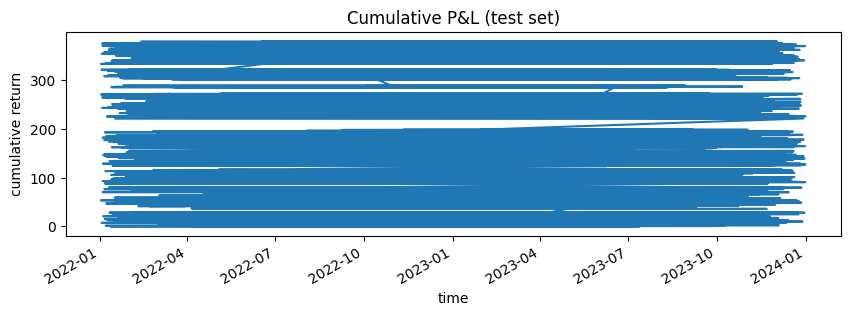

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

ax = pnl.cumsum().plot(figsize=(10, 3), title="Cumulative P&L (test set)")
ax.set_ylabel("cumulative return")
plt.show()

## Results

In [8]:
summary = pd.Series({
    "Sharpe": round(sharpe, 2),
    "hit rate": round(hit_rate, 3),
    "n test hours": len(pnl),
    "6h CV R2": round(cv_scores.mean(), 3),
    "momentum coef": round(coefs["mom6"], 3),
})
print(summary)

Sharpe             12.940
hit rate            0.636
n test hours     3498.000
6h CV R2            0.255
momentum coef       1.221
dtype: float64


A high Sharpe with a 60%+ hit rate on out-of-sample hours, and the 6h horizon confirms the
signal is robust. Next step: size positions by predicted magnitude and take it to paper trading.